# EDA Générale du Dataset de Churn

Ce notebook présente une analyse exploratoire du dataset pour comprendre la structure des données, identifier les valeurs manquantes, les doublons, et avoir un premier aperçu des corrélations avant de passer à l'analyse spécifique.

In [1]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, recall_score, f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## 1. Chargement et aperçu global

In [2]:
df = pd.read_csv("customer_churn_business_dataset.csv")
display(df.head())
print(f"\nLe dataset contient {df.shape[0]} lignes et {df.shape[1]} colonnes.")

,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0



Le dataset contient 10000 lignes et 32 colonnes.


## 2. Structure des données (Types, Vides)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             10000 non-null  object 
 1   gender                  10000 non-null  object 
 2   age                     10000 non-null  int64  
 3   country                 10000 non-null  object 
 4   city                    10000 non-null  object 
 5   customer_segment        10000 non-null  object 
 6   tenure_months           10000 non-null  int64  
 7   signup_channel          10000 non-null  object 
 8   contract_type           10000 non-null  object 
 9   monthly_logins          10000 non-null  int64  
 10  weekly_active_days      10000 non-null  int64  
 11  avg_session_time        10000 non-null  float64
 12  features_used           10000 non-null  int64  
 13  usage_growth_rate       10000 non-null  float64
 14  last_login_days_ago     10000 non-null 

On observe s'il y a des valeurs manquantes. Souvent, la colonne `complaint_type` peut avoir des vides si le client n'a pas fait de plainte.

In [4]:
print("Valeurs manquantes par colonne :")
display(df.isnull().sum())

# Nettoyage immédiat pour la suite
df["complaint_type"] = df["complaint_type"].fillna("Aucune Plainte")

Valeurs manquantes par colonne :


customer_id                  0
gender                       0
age                          0
country                      0
city                         0
customer_segment             0
tenure_months                0
signup_channel               0
contract_type                0
monthly_logins               0
weekly_active_days           0
avg_session_time             0
features_used                0
usage_growth_rate            0
last_login_days_ago          0
monthly_fee                  0
total_revenue                0
payment_method               0
payment_failures             0
discount_applied             0
price_increase_last_3m       0
support_tickets              0
avg_resolution_time          0
complaint_type            2045
csat_score                   0
escalations                  0
email_open_rate              0
marketing_click_rate         0
nps_score                    0
survey_response              0
referral_count               0
churn                        0
dtype: i

## 3. Les Doublons

In [5]:
doublons = df.duplicated().sum()
print(f"Nombre de doublons stricts : {doublons}")

Nombre de doublons stricts : 0


## 4. Statistiques Descriptives
Regardons les moyennes, les écart-types et les valeurs extrêmes des variables numériques.

In [6]:
display(df.describe())

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,payment_failures,support_tickets,avg_resolution_time,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,referral_count,churn
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000
mean,45.906100,30.155700,19.672000,3.479400,15.187890,4.990800,0.019423,9.505200,34.930000,1057.018000,0.501000,1.206600,23.953210,3.486700,0.294100,0.499610,0.253575,19.110500,0.9922,0.102100
std,16.420416,17.099517,9.838003,2.302283,6.830774,2.211607,0.149567,9.799417,23.785115,1020.148233,0.711934,1.104554,9.956999,0.978631,0.543171,0.231601,0.140532,38.936619,0.9939,0.302795
min,18.000000,1.000000,0.000000,0.000000,1.000000,1.000000,-0.580000,0.000000,10.000000,10.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.100000,0.010000,-100.000000,0.0000,0.000000
25%,32.000000,16.000000,13.000000,1.000000,10.391645,3.000000,-0.080000,2.000000,20.000000,340.000000,0.000000,0.000000,17.082041,3.000000,0.000000,0.300000,0.130000,-7.000000,0.0000,0.000000
50%,46.000000,30.000000,20.000000,3.000000,15.161659,5.000000,0.020000,6.000000,30.000000,720.000000,0.000000,1.000000,23.950444,4.000000,0.000000,0.500000,0.250000,19.000000,1.0000,0.000000
75%,60.000000,45.000000,26.000000,5.000000,19.882034,6.000000,0.120000,13.000000,50.000000,1440.000000,1.000000,2.000000,30.758480,4.000000,1.000000,0.700000,0.380000,46.000000,2.0000,0.000000
max,74.000000,59.000000,54.000000,7.000000,41.996411,15.000000,0.540000,80.000000,100.000000,5900.000000,5.000000,7.000000,61.821878,5.000000,4.000000,0.900000,0.500000,100.000000,7.0000,1.000000


## 5. Corrélation entre les variables numériques

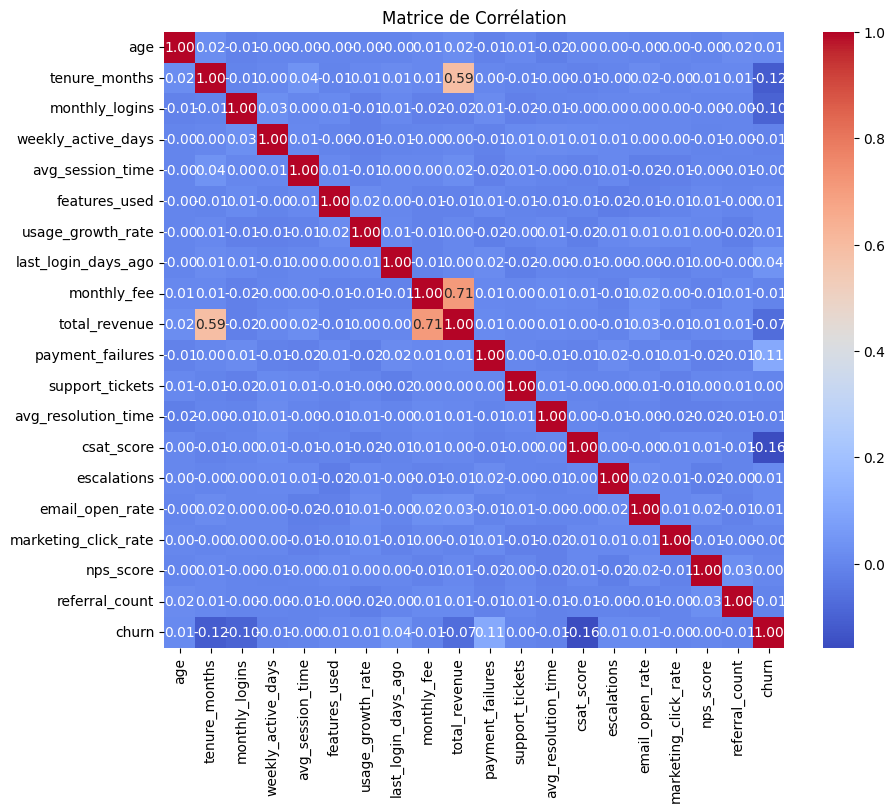

In [7]:
plt.figure(figsize=(10, 8))
num_cols = df.select_dtypes(exclude=["object"]).columns
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice de Corrélation")
plt.show()

---
# Partie 2 : Analyse du Déséquilibre des Classes (Imbalanced Data)

Maintenant que nous avons une bonne vision globale des données, concentrons-nous sur notre variable cible `churn`.

## 1. Modèle Baseline naïf
Nous allons voir que sans rééquilibrage, le modèle a tendance à prédire la classe majoritaire.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline

# Préparation basique
X = df.drop(columns=["churn", "customer_id"])
y = df["churn"]

num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

# Baseline
baseline_model = ImbPipeline([("pre", pre), ("model", LogisticRegression())])
baseline_model.fit(X, y)
y_pred_baseline = baseline_model.predict(X)

print("--- Baseline ---")
print(classification_report(y, y_pred_baseline))

## 2. Test des Techniques de Rééchantillonnage
Nous testons SMOTE, RandomUnderSampler, et Class_Weight='balanced' avec une validation croisée stratifiée (Stratified K-Fold).

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metrics = ["recall", "f1", "roc_auc"]

methods = {
    "Baseline": LogisticRegression(),
    "Class_Weight": LogisticRegression(class_weight="balanced"),
    "SMOTE": ImbPipeline([("pre", pre), ("smote", SMOTE(random_state=42)), ("model", LogisticRegression())]),
    "UnderSampling": ImbPipeline([("pre", pre), ("rus", RandomUnderSampler(random_state=42)), ("model", LogisticRegression())])
}

# Ce code est fourni comme preuve de concept. Dans les scripts finaux, nous choisirons la méthode avec le meilleur Recall/F1.

## 3. Ajustement du Seuil (Threshold Tuning)
Pour maximiser le Recall, nous pouvons baisser le seuil de décision (ex: 0.35 au lieu de 0.5).

In [ ]:
y_proba = baseline_model.predict_proba(X)[:, 1]
seuil = 0.35
y_pred_seuil = (y_proba >= seuil).astype(int)

print("--- Avec seuil ajusté (0.35) ---")
print(classification_report(y, y_pred_seuil))

# Conclusion: Nous utiliserons Class_Weight ou SMOTE dans nos scripts d'entraînement !